# Exoplanet Analysis Tools - 05: The Rossiter-McLaughlin effect

When a planet transits, it successively hides the approaching (blue-shifted) and
receding (red-shifted) halves of the rotating stellar disk, producing an anomalous
radial-velocity signal during transit: the **Rossiter-McLaughlin (RM) effect**. Its
shape encodes the **sky-projected spin-orbit obliquity** (lambda) and the **projected
stellar rotation velocity** (v sin i).

This notebook shows how to fit the RM effect with the package, using the classical
analytical model of [Ohta, Taruya & Suto (2005)](https://ui.adsabs.harvard.edu/abs/2005ApJ...622.1118O/abstract),
which is implemented in the ``rmlib`` module and plugs directly into the same MCMC
machinery used elsewhere in the package. We use real GHOST spectrograph RVs of
**WASP-108 b** taken across a transit.

We cover:
1. The RM model and its parameters
2. Loading RV-around-transit data
3. An **RM-only fit** (fit lambda and v sin i, orbit fixed)
4. Building RM priors from a system JSON file
5. Notes on the **joint photometry + RV + RM** fit

## 1. The RM model and its parameters

``rmlib.rm_rv_anomaly`` computes the RM velocity anomaly for one planet, and
``rmlib.rm_model`` returns the full model (Keplerian orbit + RM anomaly). The RM
anomaly reuses the transit geometry (``a``, ``inc``, ``rp``) and eccentricity of the
standard per-planet parameters, and adds three RM-specific parameters:

| parameter | meaning |
|-----------|---------|
| ``lambda_{iii}`` | sky-projected spin-orbit obliquity [deg] |
| ``vsini_{iii}``  | projected stellar rotation velocity (same velocity units as the RVs) |
| ``omega_rm_{iii}`` | argument of periastron for the RM geometry [deg] (usually = orbital omega) |
| ``ldc_{iii}`` | linear limb-darkening coefficient for the RM model (defaults to ``u0``) |

Let's visualize how the RM anomaly changes with the obliquity: 

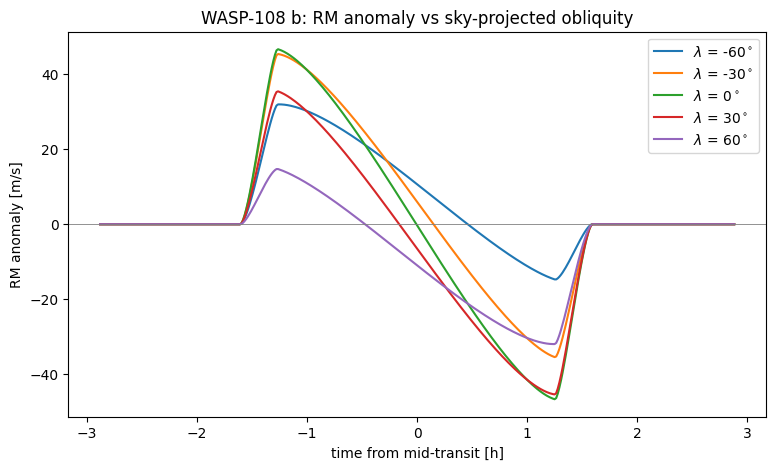

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from exoplanet_analysis import rmlib

# WASP-108 b geometry (Rp/Rs, a/Rs, inc from the literature); RVs here are in km/s
base = {
    "per_000": 2.6755463, "tc_000": 2460076.6116,
    "k_000": 0.1178, "esinw_000": 0.0, "ecosw_000": 0.0,
    "a_000": 7.05, "inc_000": 88.49, "rp_000": 0.1117,
    "vsini_000": 4.7, "omega_rm_000": 90.0, "ldc_000": 0.38,
    "rvsys_000": 0.0, "trend_000": 0.0, "quadtrend_000": 0.0,
}
t = np.linspace(base["tc_000"] - 0.12, base["tc_000"] + 0.12, 400)

plt.figure(figsize=(9, 5))
for lam in (-60, -30, 0, 30, 60):
    pp = dict(base); pp["lambda_000"] = lam
    rm = rmlib.rm_rv_anomaly(t, pp, 0) * 1000.0   # km/s -> m/s for display
    plt.plot((t - base["tc_000"]) * 24, rm, label=r"$\lambda$ = {}$^\circ$".format(lam))
plt.axhline(0, color="grey", lw=0.6)
plt.xlabel("time from mid-transit [h]"); plt.ylabel("RM anomaly [m/s]")
plt.title("WASP-108 b: RM anomaly vs sky-projected obliquity"); plt.legend()
plt.show()

The anomaly is antisymmetric for an aligned orbit (lambda = 0) and becomes
increasingly distorted as the obliquity grows - this asymmetry is what the fit
measures.

## 2. Load the RV data taken across a transit

The GHOST RVs are standard ``.rdb`` files (``rjd``, ``vrad``, ``svrad``) in **km/s**.
We load them with ``rvutils.read_rv_time_series``. Because the RM ``vsini`` is naturally
expressed in km/s here, we keep the RVs in km/s (``conv_factor=1``) so the velocity
units are consistent throughout the fit.

In [2]:
import os, shutil
from exoplanet_analysis import fitlib, rvutils, priorslib

DATA = "data/WASP-108/"
os.makedirs("outputs", exist_ok=True)
priors_file = "outputs/WASP-108_rm.pars"
shutil.copyfile(DATA + "WASP-108_rm.pars", priors_file)

rv_files = [DATA + "WASP-108_ghost_blue_ccfrv_corr.rdb",
            DATA + "WASP-108_ghost_red_ccfrv_corr.rdb"]
labels = ["GHOST blue", "GHOST red"]

bjds, rvs, rverrs = [], [], []
for f in rv_files:
    b, r, e = rvutils.read_rv_time_series(f, conv_factor=1.)   # keep km/s
    bjds.append(b); rvs.append(r); rverrs.append(e)
    print("{:12s}: {:2d} points | median RV {:.4f} km/s".format(labels[len(bjds)-1], len(b), np.median(r)))

GHOST blue  : 27 points | median RV 48.5304 km/s
GHOST red   : 56 points | median RV 48.5308 km/s


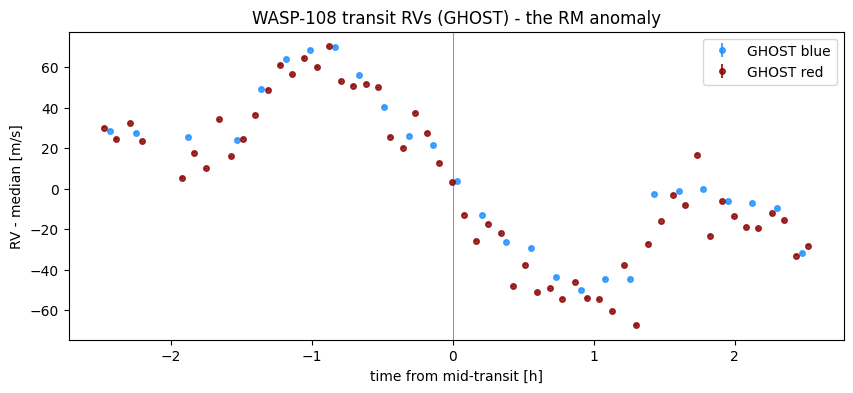

In [3]:
tc0 = 2460076.6116
colors = ["dodgerblue", "darkred"]
plt.figure(figsize=(10, 4))
for i in range(len(rvs)):
    plt.errorbar((bjds[i] - tc0) * 24, (rvs[i] - np.median(rvs[i])) * 1000, yerr=rverrs[i] * 1000,
                 fmt="o", ms=4, color=colors[i], label=labels[i], alpha=0.8)
plt.axvline(0, color="grey", lw=0.6)
plt.xlabel("time from mid-transit [h]"); plt.ylabel("RV - median [m/s]")
plt.title("WASP-108 transit RVs (GHOST) - the RM anomaly"); plt.legend()
plt.show()

## 3. RM-only fit

The RM priors file has the standard structure, with the orbital and geometric
parameters (period, a/Rs, inclination, Rp/Rs, ...) **fixed** from a prior transit
analysis, and the RM parameters lambda and v sin i left **free**. Let's look at it: 

In [4]:
print(open(priors_file).read())

# WASP-108 b Rossiter-McLaughlin priors (exoplanet_analysis _000 format)
# Star
teff	FIXED	5975.76
ms	FIXED	1.0997
rs	FIXED	1.3441
n_planets	FIXED	1
transit_000	FIXED	1
# Orbit (from RM analysis; RVs in km/s so k, vsini in km/s)
per_000	FIXED	2.6755463
tc_000	Uniform	2460076.5,2460076.7,2460076.6116
k_000	Normal	0.1178,0.0035
esinw_000	FIXED	0.0
ecosw_000	FIXED	0.0
rvsys_000	FIXED	0.0
trend_000	FIXED	0.0
quadtrend_000	FIXED	0.0
# Transit geometry (needed by the RM model)
a_000	FIXED	7.05
inc_000	FIXED	88.49
rp_000	FIXED	0.1117141671
u0_000	FIXED	0.3785423378
u1_000	FIXED	0.0
# Rossiter-McLaughlin parameters
lambda_000	Uniform	-180,180,0.0
vsini_000	Normal_positive	4.7,0.8
omega_rm_000	FIXED	90.0
# ldc_000 is OMITTED here so the RM model shares the transit limb
# darkening (u0_000/u1_000 -> linear). Uncomment the next line to give
# the RM (GHOST) bandpass its own independent coefficient instead:
#ldc_000	Uniform	-1.0,1.0,0.3785423378



The workflow mirrors the ordinary RV fit, with one difference: we call
``fitlib.read_rm_priors`` and ``fitlib.fitRMWithMCMC`` (a thin wrapper around the RV
fit that turns the RM anomaly on). The RM parameters flow through the same MCMC and
output machinery.

In [5]:
priors = fitlib.read_rm_priors(priors_file, len(rvs), verbose=False)
posterior = fitlib.guess_rvcalib(priors, bjds, rvs, prior_type="Normal", plot=False)
print("free parameters:", posterior["labels"])

median_rv (no prior model considered) =  48.53038
median_rv= 48.544276920579684
median_rv (no prior model considered) =  48.53078
median_rv= 48.53467688530296
free parameters: ['k_000', 'tc_000', 'lambda_000', 'vsini_000', 'rv_d00', 'rv_d01']


### Limb darkening: shared with the transit, or independent?

The RM effect and the transit are darkened by the *same* stellar limb darkening. The
package makes this link explicit:

- **Omit** ``ldc_{iii}`` from the priors and the RM model uses the **transit** limb
  darkening — the quadratic ``u0``/``u1`` pair converted to an effective linear
  coefficient, ``eps = u0 + (2/3) u1``. This is the right choice when the RM
  (spectroscopic) data and the transit photometry cover the **same bandpass**.
- **Include** ``ldc_{iii}`` and the RM data gets its **own** coefficient — appropriate
  when the RM bandpass **differs** from the photometric one.

For different photometric bandpasses, the transit fit already supports per-instrument
``u0_inst``/``u1_inst`` coefficients, and the RM model can be tied to any of them by a
bandpass index. The helper ``rmlib.rm_ldc_report`` states which case you are in, and the
fit prints it when ``verbose=True``.

In this notebook the RM priors file omits ``ldc``, so the GHOST RM shares the transit
limb darkening:

In [6]:
from exoplanet_analysis import rmlib
# after reading the priors, inspect how the RM limb darkening is configured
_pp = priors["planet_params"]
print(rmlib.rm_ldc_report(_pp, 0))
print("effective linear eps from u0/u1:",
      rmlib.quadratic_to_linear_ld(_pp["u0_000"], _pp.get("u1_000", 0.0)))

RM limb darkening: TIED to the transit limb darkening (u0_000/u1_000 -> linear eps = 0.3785); RM and transit share the same bandpass. Add an ldc_000 prior to use an independent coefficient instead.
effective linear eps from u0/u1: 0.3785423378


In [7]:
posterior = fitlib.fitRMWithMCMC(bjds, rvs, rverrs, posterior,
                                 nwalkers=32, niter=2000, burnin=600,
                                 samples_filename="outputs/WASP-108_rm_samples.h5",
                                 rvdatalabels=labels, verbose=True, plot=False)

Free parameters before MCMC fit:
k_000 = 0.1178
tc_000 = 2460076.6116
lambda_000 = 0.0
vsini_000 = 4.7
rv_d00 = 48.544276920579684
rv_d01 = 48.53467688530296
RM limb darkening: TIED to the transit limb darkening (u0_000/u1_000 -> linear eps = 0.3785); RM and transit share the same bandpass. Add an ldc_000 prior to use an independent coefficient instead.
initializing emcee sampler ...
Running MCMC ...
N_walkers= 32  ndim= 6


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 5/2000 [00:00<00:41, 47.90it/s]

  0%|          | 10/2000 [00:00<00:43, 45.97it/s]

  1%|          | 15/2000 [00:00<00:42, 46.42it/s]

...

 99%|█████████▉| 1987/2000 [00:40<00:00, 47.50it/s]

100%|█████████▉| 1992/2000 [00:40<00:00, 47.95it/s]

100%|█████████▉| 1997/2000 [00:40<00:00, 47.94it/s]

100%|██████████| 2000/2000 [00:40<00:00, 49.17it/s]

Obtaining best fit RV calibration parameters from pdfs ...
RV CALIBRATION Fit parameters:
rv_d00 = 48.54127870625835 + 7.376151372540107e-05 - 7.228850247997798e-05
rv_d01 = 48.53491838273565 + 5.424607033432949e-05 - 5.2650794543751545e-05
----------------
Output RV CALIBRATION posterior:  rv_calibration_posterior.pars
Obtaining best fit planet parameters from pdfs ...
----------------
PLANET 1 Fit parameters:
k_000 = 0.0804431234349658 + 0.00025353805981576105 - 0.00026142835071966963
tc_000 = 2460076.611244007 + 8.564908057451248e-06 - 8.266419172286987e-06
lambda_000 = 8.609045985311827 + 0.2606414808402473 - 0.2683368101806707
vsini_000 = 5.7255150970793185 + 0.007741999373140018 - 0.007604181836448731
----------------
Output PLANET posterior:  outputs/WASP-108_rm_posterior.pars


### The fitted RM model

Let's overlay the best-fit RM model (orbit + anomaly, with the per-dataset systemic
velocity removed) on the data: 

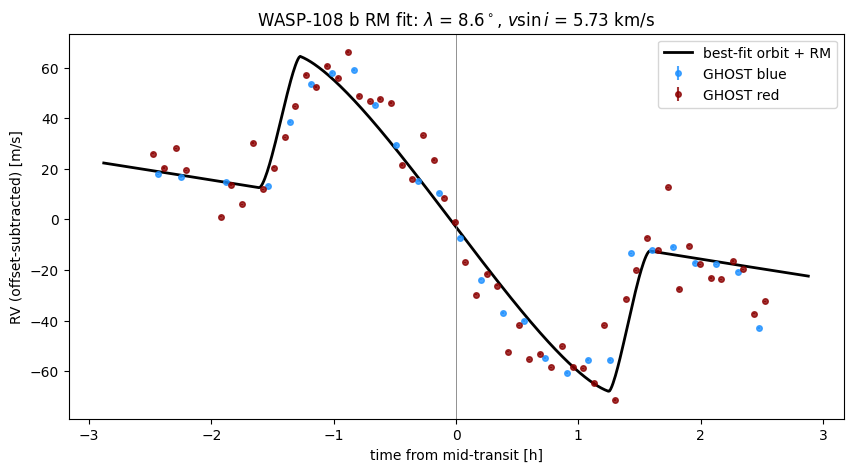

In [8]:
pp = posterior["planet_params"]
rc = posterior["rvcalib_params"]
lam_fit = pp["lambda_000"]; vsini_fit = pp["vsini_000"]

tmodel = np.linspace(tc0 - 0.12, tc0 + 0.12, 600)
rm_full = rmlib.rm_model(tmodel, pp, 0, include_orbit=True, include_trend=False)

plt.figure(figsize=(10, 5))
for i in range(len(rvs)):
    off = rc['rv_d{0:02d}'.format(i)]
    plt.errorbar((bjds[i] - tc0) * 24, (rvs[i] - off) * 1000, yerr=rverrs[i] * 1000,
                 fmt="o", ms=4, color=colors[i], label=labels[i], alpha=0.8)
plt.plot((tmodel - tc0) * 24, rm_full * 1000, "-", color="k", lw=2, label="best-fit orbit + RM")
plt.axvline(0, color="grey", lw=0.6)
plt.xlabel("time from mid-transit [h]"); plt.ylabel("RV (offset-subtracted) [m/s]")
plt.title(r"WASP-108 b RM fit: $\lambda$ = {:.1f}$^\circ$, $v\sin i$ = {:.2f} km/s".format(lam_fit, vsini_fit))
plt.legend()
plt.show()

### Corner plot and results

The obliquity and rotation velocity are the parameters of interest. Compare with the
published values for WASP-108 b (lambda approximately 6 deg, v sin i approximately
5.7 km/s - consistent with an aligned orbit).

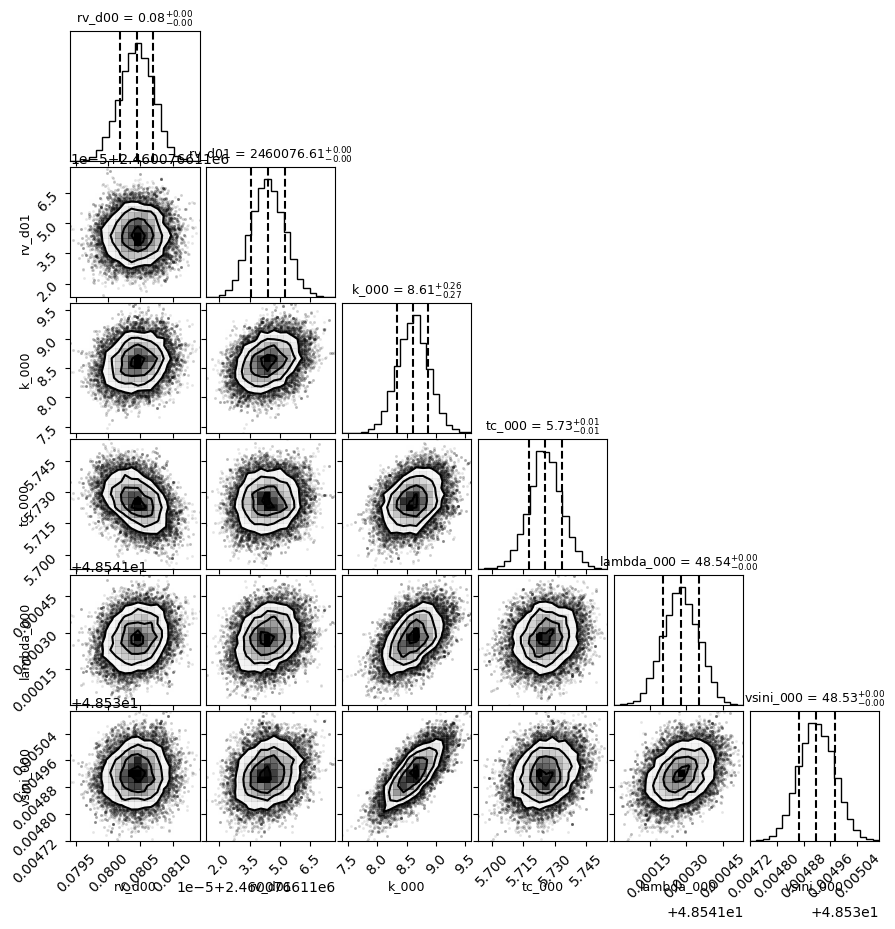

In [9]:
import corner, emcee
backend = emcee.backends.HDFBackend("outputs/WASP-108_rm_samples.h5", read_only=True)
flat = backend.get_chain(discard=600, flat=True)
lbls = list(posterior["labels"])
fig = corner.corner(flat, labels=lbls, quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_kwargs={"fontsize": 9}, label_kwargs={"fontsize": 9})
fig.set_size_inches(9, 9)
plt.show()

In [10]:
print(open("outputs/WASP-108_rm_posterior.pars").read())

# Parameter_ID	Prior_Type	Values
teff	FIXED	5975.76
ms	FIXED	1.0997
rs	FIXED	1.3441
n_planets	FIXED	1.0
k_000	Normal	0.0804431234,0.0002574832
tc_000	Normal	2460076.6112440070,0.0000084157
per_000	FIXED	2.6755463
esinw_000	FIXED	0.0
ecosw_000	FIXED	0.0
rvsys_000	FIXED	0.0
trend_000	FIXED	0.0
quadtrend_000	FIXED	0.0
a_000	FIXED	7.05
rp_000	FIXED	0.1117141671
inc_000	FIXED	88.49
u0_000	FIXED	0.3785423378
u1_000	FIXED	0.0
lambda_000	Normal	8.6090459853,0.2644891455
vsini_000	Normal	5.7255150971,0.0076730906
omega_rm_000	FIXED	90.0



## 4. Building RM priors from a system JSON file

The RM parameters are also part of the JSON system-parameters format. Setting a
planet's ``spinorbit_obliquity`` (and the star's ``vsini``) is enough for the JSON to
generate a valid RM priors file, so the whole RM workflow is available through the
system-parameters interface too.

In [11]:
from exoplanet_analysis import systemlib

system = systemlib.create_template(n_planets=1, system_name="WASP-108")
star = system["star A"]
star["teff"] = [5975.76, None]; star["mass"] = [1.0997, None]; star["radius"] = [1.3441, None]
star["vsini"] = [4.7, 0.8]                       # km/s (Normal prior)
star["limb_darkening_coeffs"] = [{"value": 0.38, "prior": "Uniform", "min": -1.0, "max": 1.0}, [0.0, None]]

pl = system["planet b"]
pl["orbital_period_days"] = [2.6755463, None]
pl["transit_time_bjd"] = {"value": 2460076.6116, "prior": "Uniform", "min": 2460076.5, "max": 2460076.7}
pl["orbital_sma_rstar"] = [7.05, None]
pl["orbital_inc"] = [88.49, None]
pl["radius_rstar"] = [0.1117141671, None]
pl["rv_semi_amplitude"] = [0.1178, 0.0035]       # km/s
pl["orbital_ecc"] = [0.0, None]; pl["orbital_omega"] = [90.0, None]
pl["spinorbit_obliquity"] = {"value": 0.0, "prior": "Uniform", "min": -180, "max": 180}   # lambda (free)

# The presence of an obliquity triggers emission of the RM parameters:
for line in systemlib.system_to_pars_lines(system):
    if any(k in line for k in ("lambda", "vsini", "omega_rm", "ldc")):
        print(line.strip())

lambda_000	Uniform	-180,180,0
vsini_000	Normal	4.7,0.8
omega_rm_000	FIXED	90
ldc_000	Uniform	-1,1,0.38


## 5. Joint photometry + RV + RM fit

The RM anomaly can also be added to the **joint** transit + RV fit, so that the
photometry, the orbital RVs, and the RM RVs are modelled simultaneously and share the
geometry. This is done with the same ``fitlib.fitTransitsAndRVsWithMCMC`` routine used
in notebook 04, passing ``include_rm=True``:

```python
posterior = fitlib.fitTransitsAndRVsWithMCMC(
    tr_times, fluxes, fluxerrs, rv_times, rvs, rverrs, posterior,
    nwalkers=32, niter=2000, burnin=600,
    samples_filename="outputs/joint_rm_samples.h5",
    include_rm=True,          # <-- adds the RM anomaly to the RV model
    verbose=True, plot=True)
```

For this to work, the priors file must contain the RM parameters (``lambda``,
``vsini``, ...) for the transiting planet, and at least one of the RV datasets should
sample the transit window so that the RM anomaly is constrained. Everything else -
building the priors, the initial guesses, the calibration, the output posterior files -
is identical to the ordinary joint fit, and the fitted RM parameters are written to the
same posterior ``.pars`` and JSON files.

### Summary

- ``rmlib`` implements the Ohta et al. (2005) analytical RM model, sharing the
  package's Keplerian and eccentricity machinery.
- ``fitlib.read_rm_priors`` + ``fitlib.fitRMWithMCMC`` fit the RM effect from RVs
  around transit (obliquity + v sin i), reusing the RV-fit MCMC infrastructure.
- ``fitlib.fitTransitsAndRVsWithMCMC(..., include_rm=True)`` adds the RM anomaly to the
  joint photometry + RV fit.
- RM parameters round-trip through both the ``.pars`` priors/posteriors and the JSON
  system-parameters format.
- The ``rm_fit`` command-line tool exposes the RM-only fit (run ``rm_fit -h``).